In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/emotions-dataset-for-nlp/val.txt
/kaggle/input/emotions-dataset-for-nlp/test.txt
/kaggle/input/emotions-dataset-for-nlp/train.txt
/kaggle/input/jigsaw-toxic-comment-classification-challenge/train.csv.zip
/kaggle/input/jigsaw-toxic-comment-classification-challenge/sample_submission.csv.zip
/kaggle/input/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip
/kaggle/input/jigsaw-toxic-comment-classification-challenge/test.csv.zip


In [2]:
import re # regular expression for pre-procesing
import emoji #to convert emoji to text for bert
from textblob import TextBlob # hanfles spelling mistakes
!pip install transformers

# **Load the Data**

In [3]:
# Load emotion dataset
emotion_train = pd.read_csv('/kaggle/input/emotions-dataset-for-nlp/train.txt')
emotion_test = pd.read_csv('/kaggle/input/emotions-dataset-for-nlp/test.txt')

num_rows3 = len(emotion_train)
print(f"Total number of rows in emotion_train: {num_rows3}")

num_rows4 = len(emotion_test)
print(f"Total number of rows in emotion_test: {num_rows4}")


Total number of rows in emotion_train: 15999
Total number of rows in emotion_test: 1999


In [4]:
print(emotion_train.head())
print(emotion_test.head(5))

                     i didnt feel humiliated;sadness
0  i can go from feeling so hopeless to so damned...
1  im grabbing a minute to post i feel greedy wro...
2  i am ever feeling nostalgic about the fireplac...
3                         i am feeling grouchy;anger
4  ive been feeling a little burdened lately wasn...
  im feeling rather rotten so im not very ambitious right now;sadness
0  im updating my blog because i feel shitty;sadness                 
1  i never make her separate from me because i do...                 
2  i left with my bouquet of red and yellow tulip...                 
3  i was feeling a little vain when i did this on...                 
4  i cant walk into a shop anywhere where i do no...                 


# **VISUALIZATION**

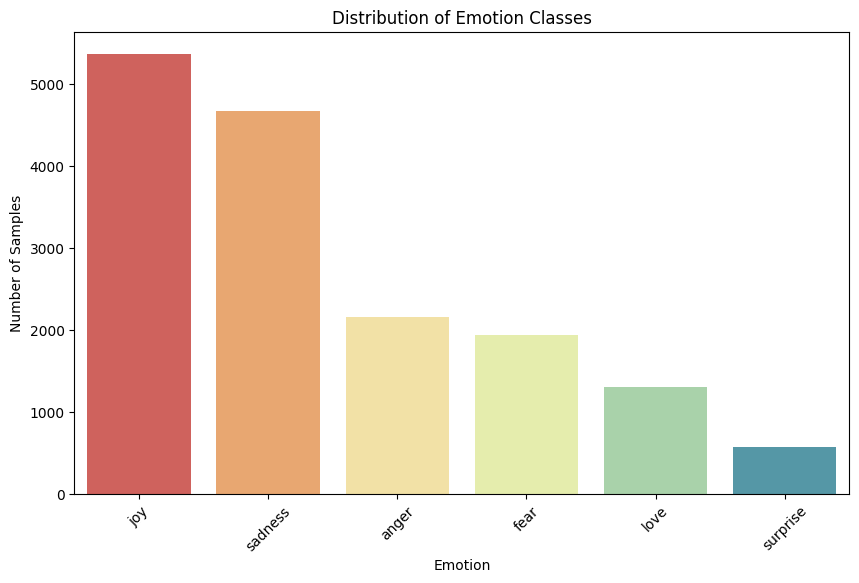

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'emotion' not in emotion_train.columns:
    col = emotion_train.columns[0]
    emotion_train[['text', 'emotion']] = emotion_train[col].str.rsplit(';', n=1, expand=True)
    emotion_train['emotion'] = emotion_train['emotion'].str.strip().str.lower()

plt.figure(figsize=(10,6))
sns.countplot(
    data=emotion_train,
    x='emotion',
    order=emotion_train['emotion'].value_counts().index,
    palette="Spectral"
)
plt.title('Distribution of Emotion Classes')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()


In [ ]:
import re
import emoji
from textblob import TextBlob  

def improved_preprocess(text, do_spelling_correction=False):
    text = re.sub(r'http\S+|www.\S+', '', text)         
    text = re.sub(r'<.*?>', '', text)                   
    text = re.sub(r'@\w+', '', text)                    
    text = re.sub(r'#\w+', '', text)                    
    text = emoji.demojize(text)                         
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)          
    text = re.sub(r'[^\x00-\x7F]+', '', text)           
    text = re.sub(r'\s+', ' ', text).strip()           
    text = text.lower()                                 

    if do_spelling_correction:
        text = str(TextBlob(text).correct())
    return text

def ensure_text_emotion_split(df):
    if {'text', 'emotion'}.issubset(df.columns):
        return df
    col = df.columns[0]
    splits = df[col].astype(str).str.rsplit(';', n=1, expand=True)
    if splits.shape[1] == 2:
        df = df.copy()
        df['text'] = splits[0].str.strip()
        df['emotion'] = splits[1].str.strip().str.lower()
        return df
    else:
        raise ValueError("Could not split the dataframe into text and emotion. Check the input format.")

emotion_train = ensure_text_emotion_split(emotion_train)
try:
    emotion_test = ensure_text_emotion_split(emotion_test)
except Exception:
    pass

emotion_train['clean_text'] = emotion_train['text'].astype(str).apply(improved_preprocess)
if 'emotion_test' in globals():
    emotion_test['clean_text'] = emotion_test['text'].astype(str).apply(improved_preprocess)



In [6]:
import os
import json
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
import torch

train_path = "/kaggle/input/emotions-dataset-for-nlp/train.txt"
val_path = "/kaggle/input/emotions-dataset-for-nlp/val.txt"
test_path = "/kaggle/input/emotions-dataset-for-nlp/test.txt"

os.makedirs("emotion_prep_outputs", exist_ok=True)


def load_data(path):
    df = pd.read_csv(path, header=None)
    df = df[0].str.split(";", n=1, expand=True)
    df.columns = ["comment", "emotion"]
    return df


def simple_clean(text):
    text = str(text).lower()
    text = text.replace("@", " ")
    text = text.replace("#", " ")
    return text.strip()


def prepare(df):
    df["clean_text"] = df["comment"].apply(simple_clean)
    return df


def encode_labels(train_df, val_df, test_df):
    le = LabelEncoder()
    le.fit(train_df["emotion"])
    train_df["emotion_id"] = le.transform(train_df["emotion"])
    val_df["emotion_id"] = le.transform(val_df["emotion"])
    test_df["emotion_id"] = le.transform(test_df["emotion"])
    mapping = {
        "emotion_to_id": {e: int(i) for i, e in enumerate(le.classes_)},
        "id_to_emotion": {int(i): e for i, e in enumerate(le.classes_)}
    }
    with open("emotion_prep_outputs/emotion_label_map.json", "w") as f:
        json.dump(mapping, f, indent=2)
    return train_df, val_df, test_df


def tokenize_and_save(df, tokenizer, enc_path, lab_path):
    enc = tokenizer(df["clean_text"].tolist(), padding="max_length", truncation=True, max_length=128, return_tensors="pt")
    torch.save(enc.data, enc_path)
    labels = torch.tensor(df["emotion_id"].values)
    torch.save(labels, lab_path)


def main():
    train_df = load_data(train_path)
    val_df = load_data(val_path)
    test_df = load_data(test_path)

    train_df = prepare(train_df)
    val_df = prepare(val_df)
    test_df = prepare(test_df)

    train_df, val_df, test_df = encode_labels(train_df, val_df, test_df)

    train_df.to_csv("emotion_prep_outputs/emotion_train_split.csv", index=False)
    val_df.to_csv("emotion_prep_outputs/emotion_val_split.csv", index=False)
    test_df.to_csv("emotion_prep_outputs/emotion_test_split.csv", index=False)

    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    tokenize_and_save(train_df, tokenizer, "emotion_prep_outputs/emotion_train_encodings.pt", "emotion_prep_outputs/emotion_train_labels.pt")
    tokenize_and_save(val_df, tokenizer, "emotion_prep_outputs/emotion_val_encodings.pt", "emotion_prep_outputs/emotion_val_labels.pt")
    tokenize_and_save(test_df, tokenizer, "emotion_prep_outputs/emotion_test_encodings.pt", "emotion_prep_outputs/emotion_test_labels.pt")


if __name__ == "__main__":
    main()


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [7]:
import os
import torch
import pandas as pd
from transformers import BertTokenizer

OUT_DIR = "emotion_prep_outputs"
PRETRAINED = "bert-base-uncased"
MAX_LEN = 128

train_csv = os.path.join(OUT_DIR, "emotion_train_split.csv")
val_csv = os.path.join(OUT_DIR, "emotion_val_split.csv")
test_csv = os.path.join(OUT_DIR, "emotion_test_split.csv")

for csv_path in [train_csv, val_csv, test_csv]:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Missing: {csv_path}. Run emotion_prep.py first.")

print("Loading CSVs...")
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)
print(f"Loaded: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

train_texts = train_df.get('clean_text', train_df.get('comment')).astype(str).tolist()
val_texts = val_df.get('clean_text', val_df.get('comment')).astype(str).tolist()
test_texts = test_df.get('clean_text', test_df.get('comment')).astype(str).tolist()

tokenizer = BertTokenizer.from_pretrained(PRETRAINED)
print("Tokenizing...")

train_enc = tokenizer(train_texts, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")
val_enc = tokenizer(val_texts, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")
test_enc = tokenizer(test_texts, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")

torch.save(train_enc.data, os.path.join(OUT_DIR, "emotion_train_encodings.pt"))
torch.save(val_enc.data, os.path.join(OUT_DIR, "emotion_val_encodings.pt"))
torch.save(test_enc.data, os.path.join(OUT_DIR, "emotion_test_encodings.pt"))

train_labels = torch.tensor(train_df['emotion_id'].values, dtype=torch.long)
val_labels = torch.tensor(val_df['emotion_id'].values, dtype=torch.long)
test_labels = torch.tensor(test_df['emotion_id'].values, dtype=torch.long)

torch.save(train_labels, os.path.join(OUT_DIR, "emotion_train_labels.pt"))
torch.save(val_labels, os.path.join(OUT_DIR, "emotion_val_labels.pt"))
torch.save(test_labels, os.path.join(OUT_DIR, "emotion_test_labels.pt"))

print("Done.")


Loading CSVs...
Loaded: train=16000, val=2000, test=2000
Tokenizing...
Done.


In [10]:
#!/usr/bin/env python3
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm

OUT_PREP_DIR = "emotion_prep_outputs"
SAVE_DIR = "saved_models/emotion_bert_rnn_v2"
PRETRAINED = "bert-base-uncased"

BATCH = 8
ACCUM = 4
EPOCHS = 8
LR_BERT = 1e-5
LR_RNN = 5e-5
WARMUP = 0.1
DECAY = 0.01
MAX_NORM = 1.0
SEED = 42

SMOOTH = 0.1
DROP_BERT = 0.2
DROP_RNN = 0.4
DROP_CLS = 0.5
PATIENCE = 3

RNN_H = 256
RNN_L = 2
RNN_BIDIR = True
LAYER_DECAY = 0.95


def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


class EncodedDataset(Dataset):
    def __init__(self, enc, lab):
        self.enc = enc
        self.lab = lab

    def __len__(self):
        return self.lab.size(0)

    def __getitem__(self, idx):
        d = {k: v[idx] for k, v in self.enc.items()}
        d["labels"] = self.lab[idx]
        return d


class LabelSmoothingLoss(nn.Module):
    def __init__(self, eps=0.1, weight=None):
        super().__init__()
        self.eps = eps
        self.weight = weight

    def forward(self, preds, target):
        n = preds.size(-1)
        logp = F.log_softmax(preds, dim=-1)

        with torch.no_grad():
            dist = torch.zeros_like(logp)
            dist.fill_(self.eps / (n - 1))
            dist.scatter_(1, target.unsqueeze(1), 1 - self.eps)

        loss = -(dist * logp).sum(dim=1)
        if self.weight is not None:
            loss = loss * self.weight[target]
        return loss.mean()


class BERT_RNN(nn.Module):
    def __init__(self, pretrained, labels):
        super().__init__()
        self.bert = BertModel.from_pretrained(pretrained)
        self.bert.config.hidden_dropout_prob = DROP_BERT
        self.bert.config.attention_probs_dropout_prob = DROP_BERT

        hidden = self.bert.config.hidden_size
        out_dim = RNN_H * (2 if RNN_BIDIR else 1)

        self.rnn = nn.LSTM(
            hidden, RNN_H, RNN_L,
            dropout=DROP_RNN if RNN_L > 1 else 0,
            bidirectional=RNN_BIDIR,
            batch_first=True
        )

        self.norm = nn.LayerNorm(out_dim)
        self.drop = nn.Dropout(DROP_CLS)
        self.fc = nn.Linear(out_dim, labels)

    def forward(self, ids, mask):
        x = self.bert(ids, attention_mask=mask).last_hidden_state
        _, (h, _) = self.rnn(x)
        if RNN_BIDIR:
            h = torch.cat((h[-2], h[-1]), dim=1)
        else:
            h = h[-1]
        return self.fc(self.drop(self.norm(h)))


def layerwise_params(model):
    no_decay = ["bias", "LayerNorm.weight"]
    layers = list(model.bert.encoder.layer)
    n = len(layers)
    params = []

    # Embeddings
    emb_lr = LR_BERT * (LAYER_DECAY ** n)
    emb = model.bert.embeddings.named_parameters()
    params.append({"params": [p for n1, p in emb if not any(nd in n1 for nd in no_decay)],
                   "lr": emb_lr, "weight_decay": DECAY})
    params.append({"params": [p for n1, p in emb if any(nd in n1 for nd in no_decay)],
                   "lr": emb_lr, "weight_decay": 0})

    # Encoder layers
    for i, layer in enumerate(layers):
        lr = LR_BERT * (LAYER_DECAY ** (n - 1 - i))
        named = list(layer.named_parameters())
        params.append({"params": [p for n1, p in named if not any(nd in n1 for nd in no_decay)],
                       "lr": lr, "weight_decay": DECAY})
        params.append({"params": [p for n1, p in named if any(nd in n1 for nd in no_decay)],
                       "lr": lr, "weight_decay": 0})

    # Pooler
    pool = model.bert.pooler.named_parameters()
    params.append({"params": [p for n1, p in pool if "bias" not in n1],
                   "lr": LR_BERT, "weight_decay": DECAY})
    params.append({"params": [p for n1, p in pool if "bias" in n1],
                   "lr": LR_BERT, "weight_decay": 0})

    # RNN + classifier
    rnn_params = list(model.rnn.named_parameters()) + \
                 list(model.norm.named_parameters()) + \
                 list(model.fc.named_parameters())
    params.append({"params": [p for n1, p in rnn_params if not any(nd in n1 for nd in no_decay)],
                   "lr": LR_RNN, "weight_decay": DECAY})
    params.append({"params": [p for n1, p in rnn_params if any(nd in n1 for nd in no_decay)],
                   "lr": LR_RNN, "weight_decay": 0})

    return params


def evaluate(model, loader, device, loss_fn):
    model.eval()
    preds, true, losses = [], [], []
    with torch.no_grad():
        for b in loader:
            ids = b["input_ids"].to(device)
            mask = b["attention_mask"].to(device)
            y = b["labels"].to(device)

            out = model(ids, mask)
            loss = loss_fn(out, y)
            losses.append(loss.item())

            p = torch.argmax(out, 1)
            preds.extend(p.cpu().numpy())
            true.extend(y.cpu().numpy())

    return {
        "loss": np.mean(losses),
        "acc": accuracy_score(true, preds),
        "f1": f1_score(true, preds, average="macro", zero_division=0)
    }



set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

enc_t = torch.load(f"{OUT_PREP_DIR}/emotion_train_encodings.pt")
enc_v = torch.load(f"{OUT_PREP_DIR}/emotion_val_encodings.pt")
y_t = torch.load(f"{OUT_PREP_DIR}/emotion_train_labels.pt")
y_v = torch.load(f"{OUT_PREP_DIR}/emotion_val_labels.pt")
label_map = json.load(open(f"{OUT_PREP_DIR}/emotion_label_map.json"))
n_labels = len(label_map["id_to_emotion"])

train_loader = DataLoader(EncodedDataset(enc_t, y_t), batch_size=BATCH, shuffle=True)
val_loader = DataLoader(EncodedDataset(enc_v, y_v), batch_size=BATCH * 2)

model = BERT_RNN(PRETRAINED, n_labels).to(device)

class_w = torch.tensor(
    np.bincount(y_t.cpu().numpy(), minlength=n_labels),
    dtype=torch.float
)
class_w = (class_w.sum() / (n_labels * class_w)).to(device)

loss_fn = LabelSmoothingLoss(SMOOTH, class_w)
opt = AdamW(layerwise_params(model))

total = (len(train_loader) // ACCUM) * EPOCHS
warm = int(total * WARMUP)
sched = get_linear_schedule_with_warmup(opt, warm, total)

best_f1 = -1
wait = 0

print("=" * 70)
print(f"Training for up to {EPOCHS} epochs (early stopping patience={PATIENCE})")
print("=" * 70)

for ep in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0
    preds, trues = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {ep}/{EPOCHS} [Train]")

    opt.zero_grad()
    for i, b in enumerate(pbar):
        ids = b["input_ids"].to(device)
        mask = b["attention_mask"].to(device)
        y = b["labels"].to(device)

        out = model(ids, mask)
        loss = loss_fn(out, y) / ACCUM
        loss.backward()
        running_loss += loss.item()

        if (i + 1) % ACCUM == 0:
            nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM)
            opt.step()
            sched.step()
            opt.zero_grad()

        p = torch.argmax(out, 1)
        preds.extend(p.cpu().numpy())
        trues.extend(y.cpu().numpy())

        if (i + 1) % 100 == 0:
            acc = accuracy_score(trues, preds)
            pbar.set_postfix({"loss": f"{running_loss/(i+1):.4f}",
                              "acc": f"{acc:.4f}"})

    val = evaluate(model, val_loader, device, loss_fn)

    if val["f1"] > best_f1:
        best_f1 = val["f1"]
        wait = 0
        os.makedirs(SAVE_DIR, exist_ok=True)
        torch.save(model.state_dict(), f"{SAVE_DIR}/pytorch_model.bin")
        BertTokenizer.from_pretrained(PRETRAINED).save_pretrained(SAVE_DIR)
        print(f"Epoch {ep}: improved F1 = {best_f1:.4f}")
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopped.")
            break

print(f"Best F1: {best_f1:.4f}")





Training for up to 8 epochs (early stopping patience=3)


Epoch 1/8 [Train]: 100%|██████████| 2000/2000 [04:26<00:00,  7.49it/s, loss=0.3962, acc=0.4086]


Epoch 1: improved F1 = 0.7763


Epoch 2/8 [Train]: 100%|██████████| 2000/2000 [04:28<00:00,  7.46it/s, loss=0.1956, acc=0.8589]


Epoch 2: improved F1 = 0.8841


...

Epoch 5: improved F1 = 0.9098


Epoch 6/8 [Train]: 100%|██████████| 2000/2000 [04:28<00:00,  7.44it/s, loss=0.1454, acc=0.9544]


Epoch 6: improved F1 = 0.9099


Epoch 8/8 [Train]: 100%|██████████| 2000/2000 [04:28<00:00,  7.45it/s, loss=0.1409, acc=0.9636]


Best F1: 0.9099


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def predict_all(model, loader, device):
    model.eval()
    all_preds, all_labels, all_logits = [], [], []
    with torch.no_grad():
        for b in loader:
            ids = b["input_ids"].to(device)
            mask = b["attention_mask"].to(device)
            y = b["labels"].to(device)
            out = model(ids, mask)
            p = torch.argmax(out, 1)
            all_preds.extend(p.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_logits.extend(out.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_logits)


best_path = os.path.join(SAVE_DIR, "pytorch_model.bin")
UPLOADED_FILE = "/mnt/data/65955649-ba8d-4c76-a164-2e1e5e7a8f99.png"

state = torch.load(best_path, map_location=device)
model.load_state_dict(state)
model.to(device)

preds, trues, logits = predict_all(model, val_loader, device)

target_names = [label_map["id_to_emotion"][str(i)] for i in range(n_labels)]

report = classification_report(trues, preds, target_names=target_names, digits=4)
print("\nBEST MODEL VALIDATION CLASSIFICATION REPORT\n")
print(report)

report_path = os.path.join(SAVE_DIR, "val_classification_report.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write("Validation classification report for best model\n\n")
    f.write(report)
    
cm = confusion_matrix(trues, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=target_names, yticklabels=target_names,
    cbar_kws={'label': 'count'}
)
plt.title("Validation Confusion Matrix (Best Model)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "val_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"\nSaved classification report to: {report_path}")
print(f"Saved confusion matrix to: {cm_path}")
print(f"\nUploaded file path: {UPLOADED_FILE}")



BEST MODEL VALIDATION CLASSIFICATION REPORT

              precision    recall  f1-score   support

       anger     0.9420    0.9455    0.9437       275
        fear     0.8528    0.9292    0.8894       212
         joy     0.9801    0.9105    0.9440       704
        love     0.8173    0.9551    0.8808       178
     sadness     0.9613    0.9473    0.9542       550
    surprise     0.8090    0.8889    0.8471        81

    accuracy                         0.9305      2000
   macro avg     0.8938    0.9294    0.9099      2000
weighted avg     0.9348    0.9305    0.9314      2000


Saved classification report to: saved_models/emotion_bert_rnn_v2/val_classification_report.txt
Saved confusion matrix to: saved_models/emotion_bert_rnn_v2/val_confusion_matrix.png

Uploaded file path: /mnt/data/65955649-ba8d-4c76-a164-2e1e5e7a8f99.png


In [15]:
import torch
from transformers import BertTokenizer


labels = ['anger','fear','joy','love','sadness','surprise']

tokenizer = BertTokenizer.from_pretrained(
    "saved_models/emotion_bert_rnn_v2"
)


model = BERT_RNN(
    pretrained="bert-base-uncased",
    labels=6
)

state_dict = torch.load(
    "saved_models/emotion_bert_rnn_v2/pytorch_model.bin",
    map_location=torch.device("cpu")
)
model.load_state_dict(state_dict)
model.eval()

def predict_emotion(text):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    with torch.no_grad():
        logits = model(encoded["input_ids"], encoded["attention_mask"])

    pred_id = torch.argmax(logits, dim=1).item()
    return pred_id

# Test
idx = predict_emotion("i am amazed")
print(labels[idx])


surprise


In [16]:
# Test these diverse sentences:

test_sentences = [
    # Complex emotional narratives
    "After months of grueling preparation and countless sleepless nights doubting myself, when they finally announced my name as the winner, I felt an overwhelming surge of pure elation mixed with disbelief that brought tears to my eyes",
    
    # Subtle emotional cues
    "The house felt unnaturally quiet after she left, with only the ticking clock breaking the silence that seemed to grow heavier with each passing hour",
    
    # Mixed emotions
    "I'm thrilled about the promotion but terrified that I won't live up to the expectations and will disappoint everyone who believed in me",
    
    # Implicit emotion through context
    "When I opened the test results and saw those numbers, my hands started trembling and I had to sit down because my legs suddenly felt weak and unreliable",
    
    # Sarcasm/complex tone
    "Oh wonderful, another flat tire on the highway in the pouring rain at midnight with no cell service - this is absolutely the perfect end to my already spectacular day",
    
    # Nostalgic/bittersweet
    "Looking through old photographs of my grandmother's smile brings back the warmth of her kitchen and the sound of her laughter, making me wish I could return to those simple Sunday afternoons just one more time",
    
    # Anticipatory emotion
    "My heart races every time I hear footsteps approaching, wondering if this will finally be the moment I've been desperately waiting for all these endless weeks",
    
    # Relief
    "When the doctor walked in with a smile and said the word 'benign', I felt like a enormous weight had been lifted off my chest and I could finally breathe normally again"
]

# Test them all
print("Testing complex emotional sentences:\n")
for i, sentence in enumerate(test_sentences, 1):
    index = predict_emotion(sentence)
    emotion = labels[index]
    print(f"{i}. [{emotion.upper()}]")
    print(f"   '{sentence[:80]}...'")
    print()

Testing complex emotional sentences:

1. [JOY]
   'After months of grueling preparation and countless sleepless nights doubting mys...'

2. [SADNESS]
   'The house felt unnaturally quiet after she left, with only the ticking clock bre...'

3. [JOY]
   'I'm thrilled about the promotion but terrified that I won't live up to the expec...'

4. [FEAR]
   'When I opened the test results and saw those numbers, my hands started trembling...'

5. [JOY]
   'Oh wonderful, another flat tire on the highway in the pouring rain at midnight w...'

6. [JOY]
   'Looking through old photographs of my grandmother's smile brings back the warmth...'

7. [FEAR]
   'My heart races every time I hear footsteps approaching, wondering if this will f...'

8. [JOY]
   'When the doctor walked in with a smile and said the word 'benign', I felt like a...'



Loading model and tokenizer...
Number of emotion classes: 6
Emotion labels: {0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}
Model loaded successfully!

Loading test data...
Test dataset size: 2000

Running evaluation...
Processed 1600 samples...

EVALUATION METRICS

Overall Accuracy: 0.9240 (92.40%)

F1 Score (Micro):    0.9240
F1 Score (Macro):    0.8883
F1 Score (Weighted): 0.9257

Precision (Macro):    0.8690
Precision (Weighted): 0.9312
Recall (Macro):       0.9145
Recall (Weighted):    0.9240

Cohen's Kappa: 0.9006

PER-CLASS PERFORMANCE

              precision    recall  f1-score   support

       anger     0.9014    0.9309    0.9159       275
        fear     0.8722    0.8839    0.8780       224
         joy     0.9875    0.9108    0.9476       695
        love     0.7573    0.9811    0.8548       159
     sadness     0.9717    0.9466    0.9590       581
    surprise     0.7237    0.8333    0.7746        66

    accuracy                         0.9240 

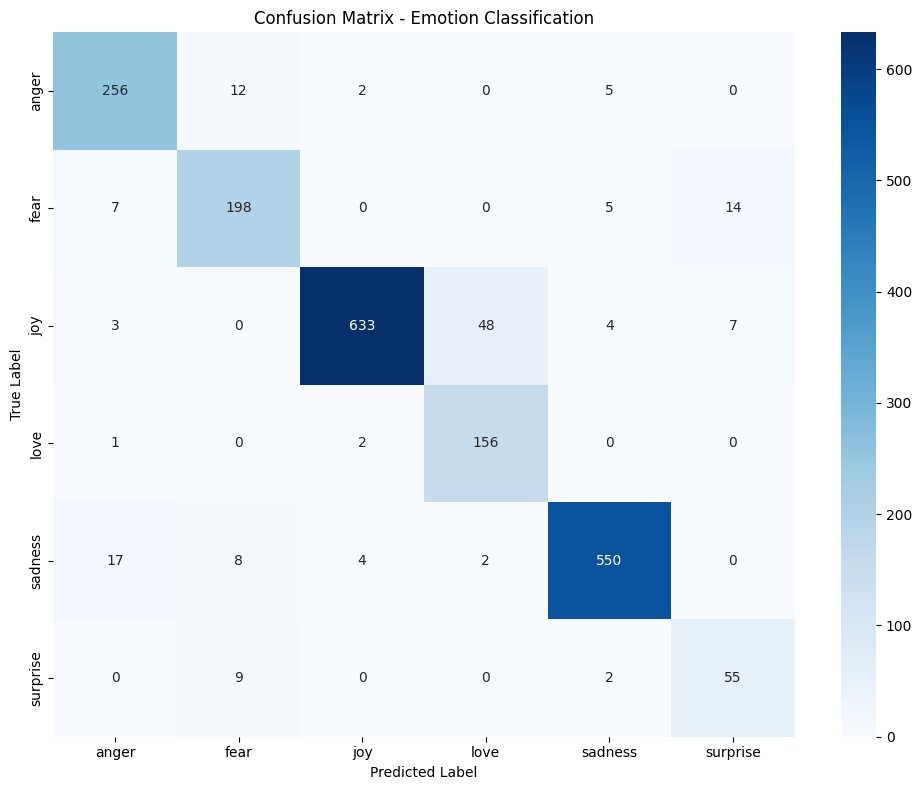

In [17]:
import os
import json
import torch
import numpy as np
import pandas as pd
from transformers import BertTokenizer
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_DIR = "saved_models/emotion_bert_rnn_v2"
DATA_DIR = "emotion_prep_outputs"
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading model and tokenizer...")

tokenizer = BertTokenizer.from_pretrained(MODEL_DIR)

with open(os.path.join(DATA_DIR, "emotion_label_map.json"), "r") as f:
    label_map = json.load(f)
    id_to_emotion = {int(k): v for k, v in label_map["id_to_emotion"].items()}
    num_labels = len(id_to_emotion)

print(f"Number of emotion classes: {num_labels}")
print(f"Emotion labels: {id_to_emotion}")

model = BERT_RNN(
    pretrained="bert-base-uncased",
    labels=num_labels
)

state_dict = torch.load(os.path.join(MODEL_DIR, "pytorch_model.bin"), map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

print("Model loaded successfully!")

print("\nLoading test data...")

test_encodings = torch.load(os.path.join(DATA_DIR, "emotion_test_encodings.pt"))
test_labels = torch.load(os.path.join(DATA_DIR, "emotion_test_labels.pt"))

test_dataset = TensorDataset(
    test_encodings['input_ids'],
    test_encodings['attention_mask'],
    test_labels
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test dataset size: {len(test_labels)}")

def evaluate_model(model, dataloader, device):
    all_preds = []
    all_labels = []
    all_logits = []
    print("\nRunning evaluation...")
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)
            logits = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_logits.extend(logits.cpu().numpy())
            if (batch_idx + 1) % 50 == 0:
                print(f"Processed {(batch_idx + 1) * BATCH_SIZE} samples...")
    return np.array(all_preds), np.array(all_labels), np.array(all_logits)

predictions, true_labels, logits = evaluate_model(model, test_loader, DEVICE)

print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)

accuracy = accuracy_score(true_labels, predictions)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

f1_micro = f1_score(true_labels, predictions, average='micro')
f1_macro = f1_score(true_labels, predictions, average='macro')
f1_weighted = f1_score(true_labels, predictions, average='weighted')

print(f"\nF1 Score (Micro):    {f1_micro:.4f}")
print(f"F1 Score (Macro):    {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

precision_macro = precision_score(true_labels, predictions, average='macro')
precision_weighted = precision_score(true_labels, predictions, average='weighted')
recall_macro = recall_score(true_labels, predictions, average='macro')
recall_weighted = recall_score(true_labels, predictions, average='weighted')

print(f"\nPrecision (Macro):    {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Macro):       {recall_macro:.4f}")
print(f"Recall (Weighted):    {recall_weighted:.4f}")

kappa = cohen_kappa_score(true_labels, predictions)
print(f"\nCohen's Kappa: {kappa:.4f}")

print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)

target_names = [id_to_emotion[i] for i in range(num_labels)]
report = classification_report(
    true_labels, 
    predictions, 
    target_names=target_names,
    digits=4
)
print("\n" + report)

print("\nPer-Class Accuracy:")
for i in range(num_labels):
    mask = true_labels == i
    if mask.sum() > 0:
        class_acc = (predictions[mask] == true_labels[mask]).sum() / mask.sum()
        print(f"  {id_to_emotion[i]:12s}: {class_acc:.4f} ({class_acc*100:.2f}%)")

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(true_labels, predictions)
print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Confusion Matrix - Emotion Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\nConfusion matrix saved to 'confusion_matrix.png'")

print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)

misclassified_indices = np.where(predictions != true_labels)[0]
print(f"\nTotal misclassified samples: {len(misclassified_indices)} / {len(true_labels)} ({len(misclassified_indices)/len(true_labels)*100:.2f}%)")

print("\nMost common misclassification pairs (true -> predicted):")
error_pairs = {}
for idx in misclassified_indices:
    pair = (id_to_emotion[true_labels[idx]], id_to_emotion[predictions[idx]])
    error_pairs[pair] = error_pairs.get(pair, 0) + 1

sorted_errors = sorted(error_pairs.items(), key=lambda x: x[1], reverse=True)
for (true_label, pred_label), count in sorted_errors[:10]:
    print(f"  {true_label:12s} -> {pred_label:12s}: {count:4d} times")

print("\n" + "="*60)
print("CONFIDENCE ANALYSIS")
print("="*60)

softmax_probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
confidences = np.max(softmax_probs, axis=1)

print(f"\nAverage confidence (all predictions): {confidences.mean():.4f}")
print(f"Average confidence (correct):          {confidences[predictions == true_labels].mean():.4f}")
print(f"Average confidence (incorrect):        {confidences[predictions != true_labels].mean():.4f}")

results_dict = {
    "accuracy": float(accuracy),
    "f1_micro": float(f1_micro),
    "f1_macro": float(f1_macro),
    "f1_weighted": float(f1_weighted),
    "precision_macro": float(precision_macro),
    "precision_weighted": float(precision_weighted),
    "recall_macro": float(recall_macro),
    "recall_weighted": float(recall_weighted),
    "cohen_kappa": float(kappa),
    "num_samples": int(len(true_labels)),
    "num_misclassified": int(len(misclassified_indices))
}

with open("test_results.json", "w") as f:
    json.dump(results_dict, f, indent=2)

print("\n" + "="*60)
print("Results saved to 'test_results.json'")
print("="*60)

print("\n" + "="*60)
print("SAMPLE PREDICTIONS")
print("="*60)

if os.path.exists(os.path.join(DATA_DIR, "emotion_test_split.csv")):
    test_df = pd.read_csv(os.path.join(DATA_DIR, "emotion_test_split.csv"))
    
    print("\n5 Random CORRECT Predictions:")
    correct_indices = np.where(predictions == true_labels)[0]
    sample_correct = np.random.choice(correct_indices, min(5, len(correct_indices)), replace=False)
    
    for idx in sample_correct:
        text = test_df.iloc[idx]['clean_text'][:100]
        true_label = id_to_emotion[true_labels[idx]]
        pred_label = id_to_emotion[predictions[idx]]
        conf = confidences[idx]
        print(f"\nText: {text}...")
        print(f"True: {true_label} | Predicted: {pred_label} | Confidence: {conf:.4f}")
    
    print("\n5 Random INCORRECT Predictions:")
    sample_incorrect = np.random.choice(misclassified_indices, min(5, len(misclassified_indices)), replace=False)
    
    for idx in sample_incorrect:
        text = test_df.iloc[idx]['clean_text'][:100]
        true_label = id_to_emotion[true_labels[idx]]
        pred_label = id_to_emotion[predictions[idx]]
        conf = confidences[idx]
        print(f"\nText: {text}...")
        print(f"True: {true_label} | Predicted: {pred_label} | Confidence: {conf:.4f}")

print("\n" + "="*60)
print("EVALUATION COMPLETE!")
print("="*60)
